In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# BAD WIRE

In [3]:
zero_img = np.zeros((512, 512))

In [4]:
bad_wire = np.random.normal(scale=0.5, size=512)
bad_wire_img = zero_img.copy()
bad_wire_img[:, 300] = bad_wire

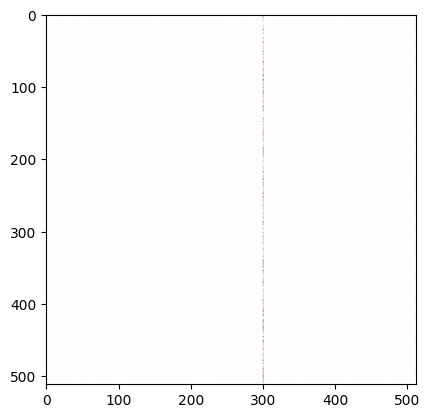

In [253]:
plt.imshow(bad_wire_img, cmap="bwr", vmin=-1, vmax=1)
np.save("bad_wire.npy", bad_wire_img)

In [6]:
# ANOMALOUS COHERENT NOISE

In [7]:
def wave_packet(t, freq=1.0, decay=0.5, phase=0.0, amplitude=1.0, t0=0):
    t = np.asarray(t)
    return amplitude * np.exp(-decay * np.abs(t-t0)) * np.sin(2 * np.pi * freq * (t-t0) + phase)

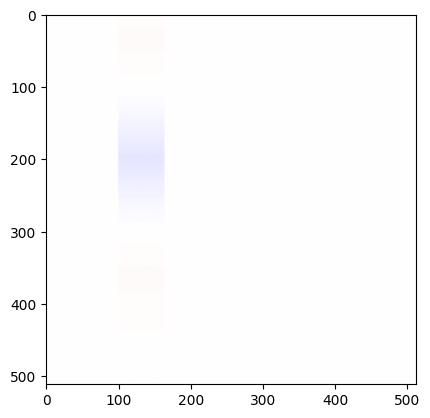

In [254]:
coh_noise = wave_packet(np.arange(512), freq=1/400., decay=1/100., amplitude=0.1, t0=200, phase=-np.pi/2)
coh_noise_img = zero_img.copy()
coh_noise_img[:, 100:164] = coh_noise.reshape((512, 1))

plt.imshow(coh_noise_img, cmap="bwr", vmin=-1, vmax=1)

np.save("coh_noise.npy", coh_noise_img)

In [9]:
import numpy as np
from scipy.signal import firwin, fftconvolve

def highpass_convolve(waveforms, cutoff=0.01, fs=1.0, numtaps=101, window='hamming',
                      axis=0):
    waveforms = np.asarray(waveforms, dtype=float)
    nyq = 0.5 * fs
    if not 0 < cutoff < nyq:
        raise ValueError(f"cutoff must be in (0, {nyq}) Hz, got {cutoff}")
    
    # Odd numtaps -> integer group delay = (numtaps - 1) / 2
    if numtaps % 2 == 0:
        numtaps += 1
    group_delay = (numtaps - 1) // 2
    
    kernel = firwin(numtaps, cutoff, fs=fs, window=window, pass_zero=False)
    
    # Reshape kernel to broadcast along the chosen axis
    shape = [1] * waveforms.ndim
    shape[axis] = -1
    kernel = kernel.reshape(shape)
    
    # 'full' convolution, then slice out the segment aligned with the 
    # input. Starting at group_delay (instead of the 'same' default of 
    # numtaps//2) removes the FIR's linear-phase delay exactly.
    full = fftconvolve(waveforms, kernel, mode='full', axes=axis)
    
    sl = [slice(None)] * waveforms.ndim
    sl[axis] = slice(group_delay, group_delay + waveforms.shape[axis])
    return full[tuple(sl)]

In [10]:
# ZERO-POLE CANCELLATION TAIL

In [11]:
import os
import h5py
print(os.environ["LD_PRELOAD"])
def pnfs2xrootd(fname):
    return fname.replace("/pnfs", "root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr")

/lib64/libXrdPosixPreload.so:libnss_wrapper.so


In [15]:
basedir = "/pnfs/sbnd/scratch/users/gputnam/DNN-ROI-images/bnb-nom/"

files = [
    "67583145_0-bnb-nom-tpc0-plane0.h5",
    "67583145_0-bnb-nom-tpc0-plane1.h5",
    "67583145_0-bnb-nom-tpc1-plane0.h5",
    "67583145_0-bnb-nom-tpc1-plane1.h5",
    "67583145_0-bnb-nom-tpc2-plane0.h5",
    "67583145_0-bnb-nom-tpc2-plane1.h5",
    "67583145_0-bnb-nom-tpc3-plane0.h5",
    "67583145_0-bnb-nom-tpc3-plane1.h5",
    "67583145_100-bnb-nom-tpc0-plane0.h5",
    "67583145_100-bnb-nom-tpc0-plane1.h5",
]

In [217]:
basedir = "/exp/sbnd/data/users/gputnam/DNN-ROI-images/"
files = [
    "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9-bnb-nom-tpc2-plane1.h5",
    "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9-bnb-nom-tpc1-plane0.h5",
    "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9-bnb-nom-tpc0-plane1.h5",
    "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9-bnb-nom-tpc3-plane0.h5",
    "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9-bnb-nom-tpc3-plane1.h5",
    "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9-bnb-nom-tpc1-plane1.h5",
    "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9-bnb-nom-tpc0-plane0.h5",
    "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9-bnb-nom-tpc2-plane0.h5",
]

for i in range(1, 10):
    files += [
        "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9%i-bnb-nom-tpc2-plane1.h5" % i,
        "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9%i-bnb-nom-tpc1-plane0.h5" % i,
        "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9%i-bnb-nom-tpc0-plane1.h5" % i,
        "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9%i-bnb-nom-tpc3-plane0.h5" % i,
        "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9%i-bnb-nom-tpc3-plane1.h5" % i,
        "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9%i-bnb-nom-tpc1-plane1.h5" % i,
        "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9%i-bnb-nom-tpc0-plane0.h5" % i,
        "/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9%i-bnb-nom-tpc2-plane0.h5" % i,
    ]


In [221]:
len(files)

80

In [218]:
allframes = {}

for F in files:
    frames = h5py.File(F, "r")
    for E in range(5):
        # Apply highpass filter to remove low-f oscillations (emulate looseLF)
        frame = highpass_convolve(frames["event_%i/deconvolved_signal" % E][:])
        max_wire = np.sum(frame, axis=0).max()
        allframes[(F, E)] = max_wire

bigevt = max(allframes, key=allframes.get)
bigevt

('/exp/sbnd/data/users/gputnam/DNN-ROI-images/82090893_9-bnb-nom-tpc0-plane0.h5',
 1)

In [224]:
bigframe = highpass_convolve(h5py.File(bigevt[0], "r")["event_%i/deconvolved_signal" % bigevt[1]][:])

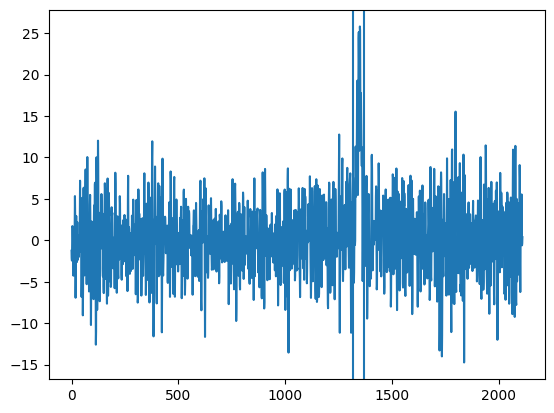

In [230]:
plt.plot(bigframe.sum(axis=0))
# plt.axvline([1150])
# plt.axvline([1300])

plt.axvline([1320])
plt.axvline([1370])

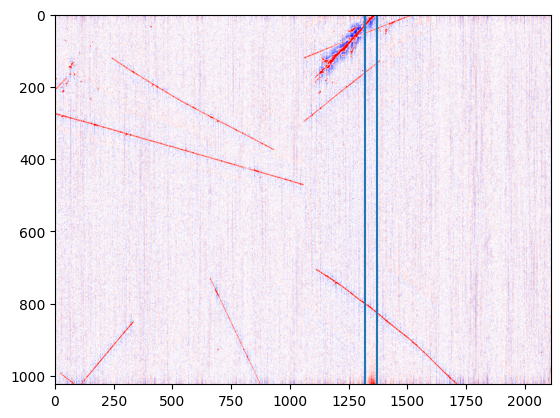

In [231]:
plt.imshow(bigframe,
          aspect="auto", vmin=-1, vmax=1, cmap="bwr")

plt.axvline([1320])
plt.axvline([1370])

In [232]:
import numpy as np
from scipy.signal import fftconvolve

def convolve_exp_tail(waveform, amplitude=1.0, decay=1.0, dt=1.0,
                      n_tau=10, n_tau_extend=1.0, axis=0):
    """
    Convolve an n-D input with a causal exponential tail along `axis`.
    The output is automatically extended past the input length so the
    decaying tail has room to ring out. The kernel is normalized so that
    DC gain is `amplitude` — a constant input maps to `amplitude` times
    that constant. The tail extends to *higher* time samples than the
    triggering signal.
    
    Parameters
    ----------
    waveform : array_like
        Input array of any dimensionality. Time runs along `axis`.
    amplitude : float
        DC gain of the filter. 1.0 preserves input amplitude.
    decay : float
        Exponential decay constant, in the same units as dt.
    dt : float
        Sample spacing. Default 1.0 -> per-bin units.
    n_tau : float
        Kernel length in units of decay (truncation point).
    n_tau_extend : float
        Output extension past the input length, in units of decay. 
        Default 1.0 -> one decay constant of tail. Set to 0 for an
        output the same length as the input.
    axis : int
        Convolution axis. Default 0.
    
    Returns
    -------
    ndarray
        Same shape as input except along `axis`, where the length is
        input_length + ceil(n_tau_extend * decay / dt).
    """
    waveform = np.asarray(waveform, dtype=float)
    
    n_in = waveform.shape[axis]
    n_extend = max(int(np.ceil(n_tau_extend * decay / dt)), 0)
    n_out = n_in # + n_extend

    if n_out > n_in:
        pad = [(0, 0)] * waveform.ndim
        pad[axis] = (0, n_out - waveform.shape[axis])
        waveform = np.pad(waveform, pad)

    # Causal 1-D kernel, peak at index 0, decaying for higher indices
    # n_kernel = max(int(np.ceil(n_tau * decay / dt)), 1)
    t = np.arange(n_out) * dt
    kernel = np.exp(-t / decay)
    kernel *= amplitude / kernel.sum()    # area = amplitude
    kernel[0] += 1
    
    # Reshape kernel to broadcast along `axis` for n-D input
    shape = [1] * waveform.ndim
    shape[axis] = -1
    kernel_nd = kernel.reshape(shape)
    
    ret = fftconvolve(waveform, kernel_nd, mode='full', axes=axis)
    return ret

In [233]:
# Take ZERO-POLE cancellation decay from ICARUS
decay_const = 48.8 / 0.4

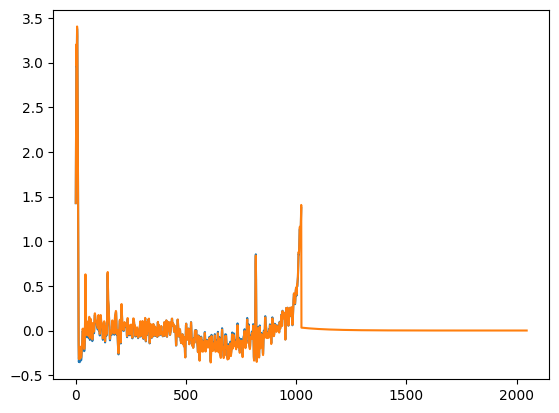

In [247]:
I = 1350

plt.plot(bigframe[:, I])
plt.plot(convolve_exp_tail(bigframe[:, I], decay=decay_const, amplitude=0.16))

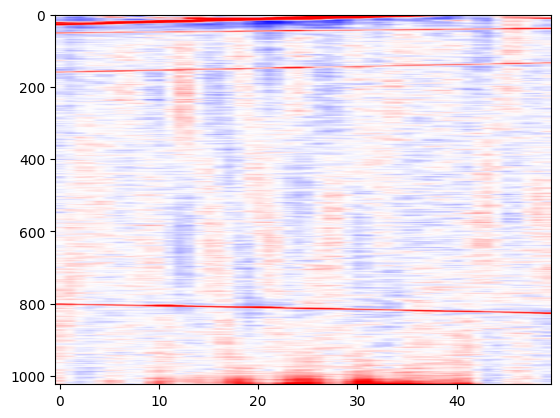

In [248]:
plt.imshow(bigframe[:, 1320:1370], aspect="auto", vmin=-1, vmax=1, cmap="bwr")

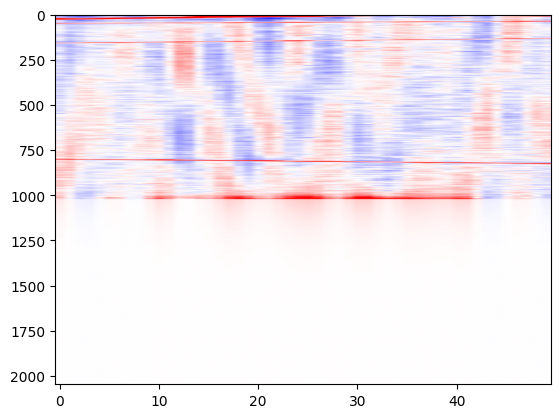

In [249]:
plt.imshow(convolve_exp_tail(bigframe[:, 1320:1370], decay=decay_const),
           aspect="auto", vmin=-1, vmax=1, cmap="bwr")

In [250]:
charge_tail = convolve_exp_tail(bigframe[:, 1320:1370], decay=decay_const)[1024:(1024+512)]

In [251]:
charge_tail_img = zero_img.copy()
charge_tail_img[:, 300:350] = charge_tail

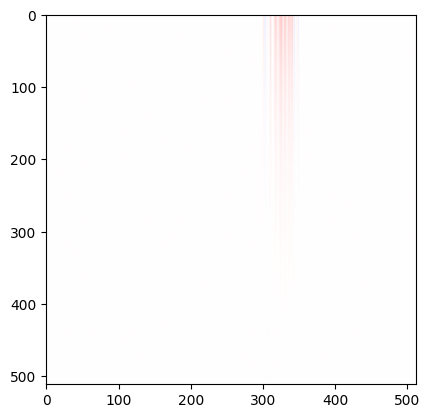

In [255]:
plt.imshow(charge_tail_img, vmin=-1, vmax=1, cmap="bwr")

np.save("charge_tail.npy", charge_tail_img)